# Flujo de datasets en notebook

Este notebook replica la funcionalidad completa de [ejecutar_flujo_datasets.ps1](ejecutar_flujo_datasets.ps1).

Prerequisitos:
- `uv` instalado y disponible en PATH.
- Credenciales de Kaggle configuradas para la descarga de HaGRID.
- ZIP de FreiHAND disponible en `datasets/` o variable de entorno `FREIHAND_ZIP`.

## 1. Imports y utilidades de ejecucion en notebook

In [2]:
import json
import os
import shutil
import subprocess
import zipfile
from pathlib import Path


def run_cmd(cmd, cwd=None):
    """Ejecuta un comando mostrando salida en tiempo real y falla en exit code != 0."""
    print("$", " ".join(str(x) for x in cmd))

    env = os.environ.copy()
    if cwd:
        cwd_path = str(Path(cwd).resolve())
        existing_pythonpath = env.get("PYTHONPATH", "").strip()
        env["PYTHONPATH"] = cwd_path if not existing_pythonpath else f"{cwd_path}{os.pathsep}{existing_pythonpath}"

    process = subprocess.Popen(
        [str(x) for x in cmd],
        cwd=str(cwd) if cwd else None,
        env=env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=False,
        bufsize=0,
    )

    assert process.stdout is not None
    while True:
        raw_line = process.stdout.readline()
        if not raw_line and process.poll() is not None:
            break
        if not raw_line:
            continue

        try:
            line = raw_line.decode("utf-8")
        except UnicodeDecodeError:
            line = raw_line.decode("cp1252", errors="replace")
        print(line, end="")

    return_code = process.wait()
    if return_code != 0:
        raise RuntimeError(f"Fallo comando con exit code {return_code}: {' '.join(str(x) for x in cmd)}")


## 2. Configuracion centralizada de variables (equivalente a env vars)

In [3]:
def env_or_default(name, default):
    return os.getenv(name, default)


CONFIG = {
    "HAGRID_DATASET": env_or_default("HAGRID_DATASET", "innominate817/hagrid-sample-30k-384p"),
    "HAGRID_DOWNLOAD_DIR": env_or_default("HAGRID_DOWNLOAD_DIR", "datasets/hagrid_sample_30k_384p"),
    "HAGRID_ANN_DIR": env_or_default("HAGRID_ANN_DIR", "datasets/ann_subsample"),
    "FREIHAND_RGB_DIR": env_or_default("FREIHAND_RGB_DIR", "datasets/FreiHAND_pub_v2/training/rgb"),
    "AUDIT_CSV": env_or_default("AUDIT_CSV", "csv/mst_real_dataset.csv"),
    "AUDIT_SUMMARY": env_or_default("AUDIT_SUMMARY", "output/mst_real_summary.json"),
    "REQUEST_MANIFEST": env_or_default("REQUEST_MANIFEST", "datasets/synthetic_mst/metadata/manifest_synthetic_requests_blocks_qc_adjusted.csv"),
    "REQUEST_SUMMARY": env_or_default("REQUEST_SUMMARY", "output/auditoria/synthetic_request_summary_blocks_qc_adjusted.json"),
    "GENERATED_MANIFEST": env_or_default("GENERATED_MANIFEST", "datasets/synthetic_mst/metadata/manifest_synthetic_generated_blocks_qc_adjusted.csv"),
    "ACCEPTED_MANIFEST": env_or_default("ACCEPTED_MANIFEST", "datasets/synthetic_mst/metadata/manifest_synthetic_accepted_blocks_qc_adjusted.csv"),
    "GENERATION_SUMMARY": env_or_default("GENERATION_SUMMARY", "output/auditoria/synthetic_generation_summary_blocks_qc_adjusted.json"),
    "QC_REPORT": env_or_default("QC_REPORT", "output/auditoria/synthetic_qc_report_blocks_qc_adjusted.json"),
    "BALANCED_MANIFEST": env_or_default("BALANCED_MANIFEST", "output/manifest_balanced_blocks.csv"),
    "BALANCED_SUMMARY": env_or_default("BALANCED_SUMMARY", "output/auditoria/manifest_balanced_blocks_summary.json"),
    "SYNTHETIC_IMAGES_DIR": env_or_default("SYNTHETIC_IMAGES_DIR", "datasets/synthetic_mst/images_blocks_qc_adjusted"),
    "SYNTHETIC_STRENGTH": env_or_default("SYNTHETIC_STRENGTH", "0.85"),
    "QC_TOLERANCE": env_or_default("QC_TOLERANCE", "1"),
    "MANO_SAMPLES_DIR": env_or_default("MANO_SAMPLES_DIR", "datasets/synthetic_mst/mano_samples_balanced"),
    "MANO_SAMPLES_MANIFEST": env_or_default("MANO_SAMPLES_MANIFEST", "datasets/synthetic_mst/metadata/manifest_mano_samples_balanced.csv"),
    "MANO_SEQUENCES_DIR": env_or_default("MANO_SEQUENCES_DIR", "data/processed/secuencias_stgcn/mano"),
    "MANO_SEQUENCES_MANIFEST": env_or_default("MANO_SEQUENCES_MANIFEST", "output/manifest_mano_secuencias.csv"),
    "MANO_MODEL": env_or_default("MANO_MODEL", "manos/models/MANO_RIGHT.pkl"),
    "MANO_SIZE": env_or_default("MANO_SIZE", "1000"),
    "MANO_POSE_MODE": env_or_default("MANO_POSE_MODE", "balanced"),
    "MANO_GENERATE": env_or_default("MANO_GENERATE", "1"),
    "BALANCED_FOR_STGCN": env_or_default("BALANCED_FOR_STGCN", env_or_default("BALANCED_MANIFEST", "output/manifest_balanced_blocks.csv")),
    "LANDMARKS_DIR": env_or_default("LANDMARKS_DIR", "data/processed/landmarks"),
    "LANDMARKS_STGCN_MANIFEST": env_or_default("LANDMARKS_STGCN_MANIFEST", "output/train_manifest_stgcn.csv"),
    "SECUENCIAS_DIR": env_or_default("SECUENCIAS_DIR", "data/processed/secuencias_stgcn"),
    "SECUENCIAS_MANIFEST": env_or_default("SECUENCIAS_MANIFEST", "output/train_manifest_stgcn_secuencias.csv"),
    "STGCN_SEED": env_or_default("STGCN_SEED", "42"),
    "STGCN_FRAMES": env_or_default("STGCN_FRAMES", "16"),
}

print(json.dumps(CONFIG, indent=2, ensure_ascii=True))

{
  "HAGRID_DATASET": "innominate817/hagrid-sample-30k-384p",
  "HAGRID_DOWNLOAD_DIR": "datasets/hagrid_sample_30k_384p",
  "HAGRID_ANN_DIR": "datasets/ann_subsample",
  "FREIHAND_RGB_DIR": "datasets/FreiHAND_pub_v2/training/rgb",
  "AUDIT_CSV": "csv/mst_real_dataset.csv",
  "AUDIT_SUMMARY": "output/mst_real_summary.json",
  "REQUEST_MANIFEST": "datasets/synthetic_mst/metadata/manifest_synthetic_requests_blocks_qc_adjusted.csv",
  "REQUEST_SUMMARY": "output/auditoria/synthetic_request_summary_blocks_qc_adjusted.json",
  "GENERATED_MANIFEST": "datasets/synthetic_mst/metadata/manifest_synthetic_generated_blocks_qc_adjusted.csv",
  "ACCEPTED_MANIFEST": "datasets/synthetic_mst/metadata/manifest_synthetic_accepted_blocks_qc_adjusted.csv",
  "GENERATION_SUMMARY": "output/auditoria/synthetic_generation_summary_blocks_qc_adjusted.json",
  "QC_REPORT": "output/auditoria/synthetic_qc_report_blocks_qc_adjusted.json",
  "BALANCED_MANIFEST": "output/manifest_balanced_blocks.csv",
  "BALANCED_SUMMAR

## 3. Funciones auxiliares del flujo (require_command, log_step, deteccion de ZIP y carpetas)

In [4]:
def require_command(command_name):
    if shutil.which(command_name) is None:
        raise RuntimeError(f"Falta el comando requerido: {command_name}")


def log_step(label):
    print(f"\n==> {label}")


def ensure_parent_directory(path_str):
    Path(path_str).parent.mkdir(parents=True, exist_ok=True)


def can_run_dataset_script(script_rel_path):
    """Valida wrappers que delegan a manos/src y evita ejecutar pasos sin implementacion."""
    script_path = Path(script_rel_path)
    if not script_path.exists():
        return False, f"No existe el script: {script_path}"

    text = script_path.read_text(encoding="utf-8")
    delegate_marker = 'TARGET = ROOT / "manos" / "src" / '
    if delegate_marker in text:
        delegated = Path("manos/src") / script_path.name
        if not delegated.exists():
            return False, f"Wrapper sin destino: {script_path} -> {delegated}"
    return True, "OK"


def detect_freihand_zip():
    freihand_zip = os.getenv("FREIHAND_ZIP", "").strip()
    if freihand_zip:
        return Path(freihand_zip)

    candidates = [
        Path("datasets/FreiHAND_pub_v2.zip"),
        Path("datasets/FreiHAND_pub_v2_eval.zip"),
    ]
    for candidate in candidates:
        if candidate.is_file():
            return candidate

    datasets_dir = Path("datasets")
    if datasets_dir.exists():
        matches = sorted(datasets_dir.rglob("FreiHAND*.zip"))
        if matches:
            return matches[0]

    return None


def find_freihand_rgb_dir():
    """Busca training/rgb de FreiHAND en ubicaciones conocidas y por escaneo recursivo."""
    candidates = [
        Path("datasets/FreiHAND_pub_v2/training/rgb"),
        Path("datasets/FreiHAND_pub_v2_eval/training/rgb"),
    ]
    for candidate in candidates:
        if candidate.is_dir():
            return candidate

    base = Path("datasets")
    if not base.exists():
        return None

    for rgb_dir in sorted(base.rglob("rgb")):
        if rgb_dir.is_dir() and rgb_dir.parent.name == "training":
            return rgb_dir

    return None


def find_hagrid_image_root():
    """Busca la carpeta hagrid_30k con las subcarpetas de clases descargadas."""
    candidates = [
        Path("datasets/hagrid_sample_30k_384p/hagrid-sample-30k-384p/hagrid_30k"),
        Path("datasets/hagrid_sample_30k_384p/hagrid_30k"),
        Path(CONFIG["HAGRID_DOWNLOAD_DIR"]) / "hagrid-sample-30k-384p" / "hagrid_30k",
    ]
    for candidate in candidates:
        if candidate.is_dir():
            return candidate

    base = Path(CONFIG["HAGRID_DOWNLOAD_DIR"])
    if base.exists():
        for candidate in sorted(base.rglob("hagrid_30k")):
            if candidate.is_dir():
                return candidate

    datasets_dir = Path("datasets")
    if datasets_dir.exists():
        for candidate in sorted(datasets_dir.rglob("hagrid_30k")):
            if candidate.is_dir():
                return candidate

    return None


def ensure_freihand_extracted(freihand_zip):
    rgb_dir = find_freihand_rgb_dir()
    if rgb_dir is not None:
        print(f"FreiHAND ya esta disponible en: {rgb_dir}")
        return rgb_dir

    if freihand_zip is None:
        raise RuntimeError("No se encontro un zip de FreiHAND. Define FREIHAND_ZIP o coloca FreiHAND*.zip en datasets/.")

    freihand_zip = Path(freihand_zip)
    if not freihand_zip.is_file():
        raise RuntimeError(f"No existe el zip de FreiHAND indicado: {freihand_zip}")

    print(f"Descomprimiendo FreiHAND desde: {freihand_zip}")
    Path("datasets").mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(freihand_zip, "r") as zf:
        zf.extractall("datasets")

    rgb_dir = find_freihand_rgb_dir()
    if rgb_dir is None:
        raise RuntimeError(
            "La extraccion de FreiHAND no produjo una carpeta training/rgb detectable dentro de datasets/."
        )

    return rgb_dir


def preview_csv(path_str, n=5):
    import csv

    path = Path(path_str)
    if not path.is_file():
        print(f"CSV no encontrado: {path}")
        return

    print(f"Preview CSV ({path}):")
    with path.open("r", encoding="utf-8", newline="") as handle:
        reader = csv.reader(handle)
        for i, row in enumerate(reader):
            print(row)
            if i >= n:
                break


def combine_audit_outputs(freihand_csv, hagrid_csv, output_csv, freihand_summary, hagrid_summary, output_summary):
    import csv

    source_files = [Path(freihand_csv), Path(hagrid_csv)]
    missing_sources = [str(path) for path in source_files if not path.is_file()]
    if missing_sources:
        raise FileNotFoundError(f"Faltan CSV de entrada para combinar: {', '.join(missing_sources)}")

    rows = []
    for src_csv in source_files:
        with src_csv.open("r", encoding="utf-8", newline="") as handle:
            reader = csv.DictReader(handle)
            rows.extend(reader)

    output_csv_path = Path(output_csv)
    output_csv_path.parent.mkdir(parents=True, exist_ok=True)
    with output_csv_path.open("w", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=["sample_id", "dataset", "mst_level", "image_path", "status"])
        writer.writeheader()
        writer.writerows(rows)

    merged_summary = {
        "freihand": json.loads(Path(freihand_summary).read_text(encoding="utf-8")).get("freihand", {}),
        "hagrid": json.loads(Path(hagrid_summary).read_text(encoding="utf-8")).get("hagrid", {}),
    }
    Path(output_summary).parent.mkdir(parents=True, exist_ok=True)
    Path(output_summary).write_text(json.dumps(merged_summary, indent=2, ensure_ascii=False), encoding="utf-8")

    return output_csv_path, Path(output_summary)


def _find_preview_images(checks, max_images=4):
    image_exts = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
    found = []

    for _, path_str in checks:
        path = Path(path_str)
        if path.is_file() and path.suffix.lower() in image_exts:
            found.append(path)
        elif path.is_dir():
            for image_path in path.rglob("*"):
                if image_path.is_file() and image_path.suffix.lower() in image_exts:
                    found.append(image_path)
                    if len(found) >= max_images:
                        return found
        if len(found) >= max_images:
            return found

    return found


def visualize_step(step_label, checks):
    """Muestra estado de artefactos y, cuando exista, una vista previa de imagenes."""
    rows = []
    for item, path_str in checks:
        path = Path(path_str)
        exists = path.exists()
        if path.is_dir():
            detail = f"dir ({sum(1 for _ in path.iterdir())} items directos)"
        elif path.is_file():
            detail = f"file ({path.stat().st_size} bytes)"
        else:
            detail = "missing"
        rows.append((item, str(path), exists, detail))

    print(f"\n[visualizacion] {step_label}")
    print("| Item | Path | Existe | Detalle |")
    print("|---|---|---|---|")
    for item, path, exists, detail in rows:
        print(f"| {item} | {path} | {'SI' if exists else 'NO'} | {detail} |")

    images = _find_preview_images(checks, max_images=4)
    if not images:
        print("Sin imagenes para previsualizar en este paso.")
        return

    try:
        import matplotlib.pyplot as plt
        from PIL import Image

        cols = min(2, len(images))
        rows_count = (len(images) + cols - 1) // cols
        _, axes = plt.subplots(rows_count, cols, figsize=(10, 4 * rows_count))

        if not isinstance(axes, (list, tuple)):
            try:
                axes = axes.flatten()
            except Exception:
                axes = [axes]
        else:
            flat_axes = []
            for ax in axes:
                try:
                    flat_axes.extend(ax)
                except Exception:
                    flat_axes.append(ax)
            axes = flat_axes

        for i, img_path in enumerate(images):
            ax = axes[i]
            with Image.open(img_path) as img:
                ax.imshow(img)
            ax.set_title(img_path.name)
            ax.axis("off")

        for j in range(len(images), len(axes)):
            axes[j].axis("off")

        plt.suptitle(f"Previsualizacion de imagenes: {step_label}")
        plt.tight_layout()
        plt.show()
    except Exception as exc:
        print(f"Aviso: no se pudo renderizar previsualizacion de imagenes ({exc}).")

## 4. Preparacion del entorno de trabajo y validacion de uv

In [5]:
ROOT_DIR = Path.cwd()
print(f"ROOT_DIR: {ROOT_DIR}")

if not (ROOT_DIR / "src").exists():
    print("Advertencia: no se detecta carpeta src en el directorio actual.")

require_command("uv")

for folder in ["datasets", "output", "csv"]:
    Path(folder).mkdir(parents=True, exist_ok=True)

print("Entorno validado.")

ROOT_DIR: c:\Users\usuario\Mateo\entrega\balanceo_datasets
Entorno validado.


## 5. Paso 1: Descarga y preparacion de HaGRID

In [5]:
log_step("1/9 Descarga de HaGRID")
run_cmd([
    "uv", "run", "python", "src/datasets/setup/download_hagrid_kaggle.py",
    "--dataset", CONFIG["HAGRID_DATASET"],
    "--download-dir", CONFIG["HAGRID_DOWNLOAD_DIR"],
    "--execute",
    "--prepare-ann-subsample",
], cwd=ROOT_DIR)


==> 1/9 Descarga de HaGRID
$ uv run python src/datasets/setup/download_hagrid_kaggle.py --dataset innominate817/hagrid-sample-30k-384p --download-dir datasets/hagrid_sample_30k_384p --execute --prepare-ann-subsample
Credenciales locales detectadas
KAGGLE_CONFIG_DIR activo: secrets\kaggle
kaggle.json local: secrets\kaggle\kaggle.json
Kaggle CLI: OK
Credenciales: secrets\kaggle\kaggle.json
Modo: EXECUTE
$ kaggle datasets download -d innominate817/hagrid-sample-30k-384p -p datasets\hagrid_sample_30k_384p --unzip
Dataset URL: https://www.kaggle.com/datasets/innominate817/hagrid-sample-30k-384p
License(s): CC-BY-SA-4.0
Resuming from 560988160 bytes (302216799 bytes left)...
100%|██████████| 823M/823M [01:10<00:00, 4.29MB/s]

Copiar: datasets\hagrid_sample_30k_384p\hagrid-sample-30k-384p\ann_train_val\call.json -> datasets\ann_subsample\call.json
Copiar: datasets\hagrid_sample_30k_384p\hagrid-sample-30k-384p\ann_train_val\dislike.json -> datasets\ann_subsample\dislike.json
Copiar: datasets\


[visualizacion] Paso 1 - HaGRID
| Item | Path | Existe | Detalle |
|---|---|---|---|
| HaGRID download | datasets\hagrid_sample_30k_384p | SI | dir (1 items directos) |
| HaGRID ann | datasets\ann_subsample | SI | dir (18 items directos) |


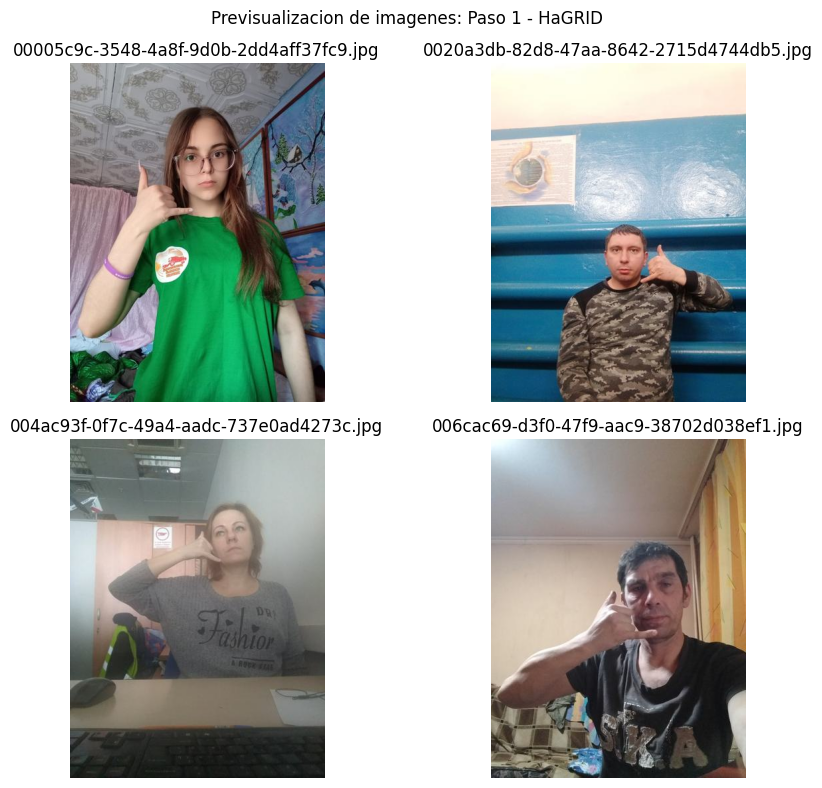

In [6]:
visualize_step("Paso 1 - HaGRID", [
    ("HaGRID download", CONFIG["HAGRID_DOWNLOAD_DIR"]),
    ("HaGRID ann", CONFIG["HAGRID_ANN_DIR"]),
])

## 6. Paso 2: Deteccion y descompresion de FreiHAND

In [7]:
log_step("2/9 Descompresion de FreiHAND")
freihand_zip_path = detect_freihand_zip()
freihand_rgb_dir = ensure_freihand_extracted(freihand_zip_path)
CONFIG["FREIHAND_RGB_DIR"] = str(freihand_rgb_dir)
print(f"FREIHAND_RGB_DIR detectado: {CONFIG['FREIHAND_RGB_DIR']}")


==> 2/9 Descompresion de FreiHAND
FreiHAND ya esta disponible en: datasets\training\rgb
FREIHAND_RGB_DIR detectado: datasets\training\rgb


In [7]:
visualize_step("Paso 2 - FreiHAND", [
    ("FreiHAND RGB", CONFIG["FREIHAND_RGB_DIR"]),
])


[visualizacion] Paso 2 - FreiHAND
| Item | Path | Existe | Detalle |
|---|---|---|---|
| FreiHAND RGB | datasets\FreiHAND_pub_v2\training\rgb | NO | missing |
Sin imagenes para previsualizar en este paso.


## 7. Paso 3: Auditoria MST real

In [8]:
log_step("3/9A Auditoria MST real - FreiHAND")
ensure_parent_directory(CONFIG["AUDIT_CSV"])
ensure_parent_directory(CONFIG["AUDIT_SUMMARY"])

AUDIT_FREIHAND_CSV = str(Path(CONFIG["AUDIT_CSV"]).with_name("mst_real_dataset_freihand.csv"))
AUDIT_FREIHAND_SUMMARY = str(Path(CONFIG["AUDIT_SUMMARY"]).with_name("mst_real_summary_freihand.json"))

run_cmd([
    "uv", "run", "python", "src/datasets/setup/generar_mst_real_datasets.py",
    "--freihand-rgb-dir", CONFIG["FREIHAND_RGB_DIR"],
    "--freihand-limit", "32560",
    "--hagrid-image-roots", "datasets/hagrid_dataset",
    "--hagrid-annotations-dir", "datasets/__empty_hagrid_annotations__",
    "--output-csv", AUDIT_FREIHAND_CSV,
    "--output-summary", AUDIT_FREIHAND_SUMMARY,
], cwd=ROOT_DIR)

print(f"FreiHAND CSV: {AUDIT_FREIHAND_CSV}")
print(f"FreiHAND summary: {AUDIT_FREIHAND_SUMMARY}")


==> 3/9A Auditoria MST real - FreiHAND
$ uv run python src/datasets/setup/generar_mst_real_datasets.py --freihand-rgb-dir datasets\training\rgb --hagrid-image-roots datasets/hagrid_dataset --hagrid-annotations-dir datasets/__empty_hagrid_annotations__ --output-csv csv\mst_real_dataset_freihand.csv --output-summary output\mst_real_summary_freihand.json
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1776677617.603176   10504 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776677617.610044   10504 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
Procesando FreiHAND...
W0000 00:00:1776677617.627380    4524 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATR

In [ ]:
log_step("3/9B Auditoria MST real - HaGRID")

AUDIT_HAGRID_CSV = str(Path(CONFIG["AUDIT_CSV"]).with_name("mst_real_dataset_hagrid.csv"))
AUDIT_HAGRID_SUMMARY = str(Path(CONFIG["AUDIT_SUMMARY"]).with_name("mst_real_summary_hagrid.json"))
HAGRID_IMAGE_ROOT = find_hagrid_image_root()
if HAGRID_IMAGE_ROOT is None:
    raise RuntimeError("No se encontro la raiz de HaGRID. Se esperaba hagrid_30k dentro de datasets/.")

print(f"HaGRID image root: {HAGRID_IMAGE_ROOT}")

run_cmd([
    "uv", "run", "python", "src/datasets/setup/generar_mst_real_datasets.py",
    "--freihand-rgb-dir", CONFIG["FREIHAND_RGB_DIR"],
    "--freihand-limit", "0",
    "--hagrid-image-roots", str(HAGRID_IMAGE_ROOT),
    "--hagrid-annotations-dir", CONFIG["HAGRID_ANN_DIR"],
    "--output-csv", AUDIT_HAGRID_CSV,
    "--output-summary", AUDIT_HAGRID_SUMMARY,
], cwd=ROOT_DIR)

combine_audit_outputs(
    AUDIT_FREIHAND_CSV,
    AUDIT_HAGRID_CSV,
    CONFIG["AUDIT_CSV"],
    AUDIT_FREIHAND_SUMMARY,
    AUDIT_HAGRID_SUMMARY,
    CONFIG["AUDIT_SUMMARY"],
)

print(f"HaGRID CSV: {AUDIT_HAGRID_CSV}")
print(f"HaGRID summary: {AUDIT_HAGRID_SUMMARY}")
print(f"CSV combinado: {CONFIG['AUDIT_CSV']}")
print(f"Summary combinado: {CONFIG['AUDIT_SUMMARY']}")


==> 3/9B Auditoria MST real - HaGRID
HaGRID image root: datasets\hagrid_sample_30k_384p\hagrid-sample-30k-384p\hagrid_30k
$ uv run python src/datasets/setup/generar_mst_real_datasets.py --freihand-rgb-dir datasets/FreiHAND_pub_v2/training/rgb --freihand-limit 0 --hagrid-image-roots datasets\hagrid_sample_30k_384p\hagrid-sample-30k-384p\hagrid_30k --hagrid-annotations-dir datasets/ann_subsample --output-csv csv\mst_real_dataset_hagrid.csv --output-summary output\mst_real_summary_hagrid.json
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1776679782.589803   13228 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776679782.596711   13228 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
Procesando FreiHAND...
Procesando HaGRID...
W0000 00:00:1776679789.918258     904 la

In [8]:
if not Path(CONFIG["AUDIT_CSV"]).is_file():
    try:
        combine_audit_outputs(
            AUDIT_FREIHAND_CSV,
            AUDIT_HAGRID_CSV,
            CONFIG["AUDIT_CSV"],
            AUDIT_FREIHAND_SUMMARY,
            AUDIT_HAGRID_SUMMARY,
            CONFIG["AUDIT_SUMMARY"],
        )
    except Exception as exc:
        print(f"Aviso: no se pudo reconstruir el audit combinado antes de la vista previa ({exc}).")

visualize_step("Paso 3 - Auditoria", [
    ("AUDIT_CSV", CONFIG["AUDIT_CSV"]),
    ("AUDIT_SUMMARY", CONFIG["AUDIT_SUMMARY"]),
])
preview_csv(CONFIG["AUDIT_CSV"], n=5)

Aviso: no se pudo reconstruir el audit combinado antes de la vista previa (name 'AUDIT_FREIHAND_CSV' is not defined).

[visualizacion] Paso 3 - Auditoria
| Item | Path | Existe | Detalle |
|---|---|---|---|
| AUDIT_CSV | csv\mst_real_dataset.csv | NO | missing |
| AUDIT_SUMMARY | output\mst_real_summary.json | NO | missing |
Sin imagenes para previsualizar en este paso.
CSV no encontrado: csv\mst_real_dataset.csv


## 8. Paso 4: Construccion de solicitudes sinteticas

In [14]:
log_step("4/9 Balanceo y generacion de solicitudes sinteticas")
for key in [
    "REQUEST_MANIFEST",
    "GENERATED_MANIFEST",
    "ACCEPTED_MANIFEST",
    "GENERATION_SUMMARY",
    "QC_REPORT",
    "BALANCED_MANIFEST",
    "BALANCED_SUMMARY",
]:
    ensure_parent_directory(CONFIG[key])

ok, reason = can_run_dataset_script("src/datasets/manos/build_synthetic_manifest.py")
if ok:
    run_cmd([
        "uv", "run", "python", "src/datasets/manos/build_synthetic_manifest.py",
        "--real-csv", CONFIG["AUDIT_CSV"],
        "--existing-accepted-csv", CONFIG["ACCEPTED_MANIFEST"],
        "--output-manifest", CONFIG["REQUEST_MANIFEST"],
        "--output-summary", CONFIG["REQUEST_SUMMARY"],
    ], cwd=ROOT_DIR)
else:
    print(f"Aviso: se omite paso 4 por script no disponible ({reason}).")


==> 4/9 Balanceo y generacion de solicitudes sinteticas
$ uv run python src/datasets/manos/build_synthetic_manifest.py --real-csv csv/mst_real_dataset.csv --existing-accepted-csv datasets/synthetic_mst/metadata/manifest_synthetic_accepted_blocks_qc_adjusted.csv --output-manifest datasets/synthetic_mst/metadata/manifest_synthetic_requests_blocks_qc_adjusted.csv --output-summary output/auditoria/synthetic_request_summary_blocks_qc_adjusted.json
Traceback (most recent call last):
  File "c:\Users\usuario\Mateo\entrega\balanceo_datasets\src\datasets\manos\build_synthetic_manifest.py", line 246, in <module>
    raise SystemExit(main())
                     ~~~~^^
  File "c:\Users\usuario\Mateo\entrega\balanceo_datasets\src\datasets\manos\build_synthetic_manifest.py", line 152, in main
    real_samples = _load_real_samples(real_paths)
  File "c:\Users\usuario\Mateo\entrega\balanceo_datasets\src\datasets\manos\build_synthetic_manifest.py", line 50, in _load_real_samples
    raise FileNotFoun

RuntimeError: Fallo comando con exit code 1: uv run python src/datasets/manos/build_synthetic_manifest.py --real-csv csv/mst_real_dataset.csv --existing-accepted-csv datasets/synthetic_mst/metadata/manifest_synthetic_accepted_blocks_qc_adjusted.csv --output-manifest datasets/synthetic_mst/metadata/manifest_synthetic_requests_blocks_qc_adjusted.csv --output-summary output/auditoria/synthetic_request_summary_blocks_qc_adjusted.json

In [15]:
visualize_step("Paso 4 - Solicitudes sinteticas", [
    ("REQUEST_MANIFEST", CONFIG["REQUEST_MANIFEST"]),
    ("REQUEST_SUMMARY", CONFIG["REQUEST_SUMMARY"]),
])
preview_csv(CONFIG["REQUEST_MANIFEST"], n=5)


[visualizacion] Paso 4 - Solicitudes sinteticas
| Item | Path | Existe | Detalle |
|---|---|---|---|
| REQUEST_MANIFEST | datasets\synthetic_mst\metadata\manifest_synthetic_requests_blocks_qc_adjusted.csv | NO | missing |
| REQUEST_SUMMARY | output\auditoria\synthetic_request_summary_blocks_qc_adjusted.json | NO | missing |
Sin imagenes para previsualizar en este paso.
CSV no encontrado: datasets\synthetic_mst\metadata\manifest_synthetic_requests_blocks_qc_adjusted.csv


## 9. Paso 5: Generacion sintetica, control de calidad y manifiesto MANO

In [ ]:
log_step("5/9 Creacion y QC de sinteticos")

ok_generate, reason_generate = can_run_dataset_script("src/datasets/manos/generate_synthetic_skin_tones.py")
ok_qc, reason_qc = can_run_dataset_script("src/datasets/manos/qc_synthetic_dataset.py")

if ok_generate:
    run_cmd([
        "uv", "run", "python", "src/datasets/manos/generate_synthetic_skin_tones.py",
        "--request-manifest", CONFIG["REQUEST_MANIFEST"],
        "--output-images-dir", CONFIG["SYNTHETIC_IMAGES_DIR"],
        "--output-manifest", CONFIG["GENERATED_MANIFEST"],
        "--output-summary", CONFIG["GENERATION_SUMMARY"],
        "--strength", CONFIG["SYNTHETIC_STRENGTH"],
    ], cwd=ROOT_DIR)
else:
    print(f"Aviso: se omite generacion sintetica ({reason_generate}).")

if ok_qc:
    run_cmd([
        "uv", "run", "python", "src/datasets/manos/qc_synthetic_dataset.py",
        "--generated-manifest", CONFIG["GENERATED_MANIFEST"],
        "--accepted-manifest", CONFIG["ACCEPTED_MANIFEST"],
        "--report-json", CONFIG["QC_REPORT"],
        "--tolerance", CONFIG["QC_TOLERANCE"],
    ], cwd=ROOT_DIR)
else:
    print(f"Aviso: se omite QC sintetico ({reason_qc}).")

if CONFIG["MANO_GENERATE"] == "1":
    print("\n==> Generacion de muestras MANO")
    run_cmd([
        "uv", "run", "python", "manos/src/generator.py",
        "--model", CONFIG["MANO_MODEL"],
        "--size", CONFIG["MANO_SIZE"],
        "--pose-mode", CONFIG["MANO_POSE_MODE"],
        "--out", CONFIG["MANO_SAMPLES_DIR"],
    ], cwd=ROOT_DIR)
else:
    print(f"\n==> Se omite generacion MANO (MANO_GENERATE={CONFIG['MANO_GENERATE']})")

run_cmd([
    "uv", "run", "python", "src/datasets/manos/build_mano_samples_manifest.py",
    "--sample-dir", CONFIG["MANO_SAMPLES_DIR"],
    "--output-manifest", CONFIG["MANO_SAMPLES_MANIFEST"],
], cwd=ROOT_DIR)


==> 5/9 Creacion y QC de sinteticos
Aviso: se omite generacion sintetica (Wrapper sin destino: src\datasets\manos\generate_synthetic_skin_tones.py -> manos\src\generate_synthetic_skin_tones.py).
Aviso: se omite QC sintetico (Wrapper sin destino: src\datasets\manos\qc_synthetic_dataset.py -> manos\src\qc_synthetic_dataset.py).

==> Generacion de muestras MANO
$ uv run python manos/src/generator.py --model manos/models/MANO_RIGHT.pkl --size 1000 --pose-mode balanced --out datasets/synthetic_mst/mano_samples_balanced
Cargando modelo: manos/models/MANO_RIGHT.pkl
Generando 1000 muestras Ã— 10 niveles MST (pose_mode=balanced) ...
  MST_1: 1000 muestras guardadas.
  MST_2: 1000 muestras guardadas.
  MST_3: 1000 muestras guardadas.
  MST_4: 1000 muestras guardadas.
  MST_5: 1000 muestras guardadas.
  MST_6: 1000 muestras guardadas.
  MST_7: 1000 muestras guardadas.
  MST_8: 1000 muestras guardadas.
  MST_9: 1000 muestras guardadas.
  MST_10: 1000 muestras guardadas.

Dataset completo: 10000 m

In [16]:
visualize_step("Paso 5 - Sinteticos y MANO", [
    ("SYNTHETIC_IMAGES_DIR", CONFIG["SYNTHETIC_IMAGES_DIR"]),
    ("GENERATED_MANIFEST", CONFIG["GENERATED_MANIFEST"]),
    ("ACCEPTED_MANIFEST", CONFIG["ACCEPTED_MANIFEST"]),
    ("QC_REPORT", CONFIG["QC_REPORT"]),
    ("MANO_SAMPLES_MANIFEST", CONFIG["MANO_SAMPLES_MANIFEST"]),
])
preview_csv(CONFIG["MANO_SAMPLES_MANIFEST"], n=5)


[visualizacion] Paso 5 - Sinteticos y MANO
| Item | Path | Existe | Detalle |
|---|---|---|---|
| SYNTHETIC_IMAGES_DIR | datasets\synthetic_mst\images_blocks_qc_adjusted | NO | missing |
| GENERATED_MANIFEST | datasets\synthetic_mst\metadata\manifest_synthetic_generated_blocks_qc_adjusted.csv | NO | missing |
| ACCEPTED_MANIFEST | datasets\synthetic_mst\metadata\manifest_synthetic_accepted_blocks_qc_adjusted.csv | NO | missing |
| QC_REPORT | output\auditoria\synthetic_qc_report_blocks_qc_adjusted.json | SI | file (800 bytes) |
| MANO_SAMPLES_MANIFEST | datasets\synthetic_mst\metadata\manifest_mano_samples_balanced.csv | SI | file (2546066 bytes) |
Sin imagenes para previsualizar en este paso.
Preview CSV (datasets\synthetic_mst\metadata\manifest_mano_samples_balanced.csv):
['sample_id', 'path', 'dataset', 'mst_level', 'mst_block', 'source_kind', 'input_csv']
['sample_00000_MST_1', 'C:\\Users\\usuario\\Mateo\\entrega\\balanceo_datasets\\datasets\\synthetic_mst\\mano_samples_balanced\\

## 10. Paso 6: Generacion de secuencias temporales MANO

In [ ]:
log_step("6/9 Generacion de secuencias temporales MANO")
Path(CONFIG["MANO_SEQUENCES_DIR"]).mkdir(parents=True, exist_ok=True)
run_cmd([
    "uv", "run", "python", "src/datasets/manos/generar_secuencias_temporales.py",
    "--input-dir", CONFIG["MANO_SAMPLES_DIR"],
    "--output-dir", CONFIG["MANO_SEQUENCES_DIR"],
    "--output-manifest", CONFIG["MANO_SEQUENCES_MANIFEST"],
    "--T", CONFIG["STGCN_FRAMES"],
    "--seed", CONFIG["STGCN_SEED"],
], cwd=ROOT_DIR)


==> 6/9 Generacion de secuencias temporales MANO
$ uv run python src/datasets/manos/generar_secuencias_temporales.py --input-dir datasets/synthetic_mst/mano_samples_balanced --output-dir data/processed/secuencias_stgcn/mano --output-manifest output/manifest_mano_secuencias.csv --T 16 --seed 42
  Procesadas 500/10000 muestras MANO
  Procesadas 1000/10000 muestras MANO
  Procesadas 1500/10000 muestras MANO
  Procesadas 2000/10000 muestras MANO
  Procesadas 2500/10000 muestras MANO
  Procesadas 3000/10000 muestras MANO
  Procesadas 3500/10000 muestras MANO
  Procesadas 4000/10000 muestras MANO
  Procesadas 4500/10000 muestras MANO
  Procesadas 5000/10000 muestras MANO
  Procesadas 5500/10000 muestras MANO
  Procesadas 6000/10000 muestras MANO
  Procesadas 6500/10000 muestras MANO
  Procesadas 7000/10000 muestras MANO
  Procesadas 7500/10000 muestras MANO
  Procesadas 8000/10000 muestras MANO
  Procesadas 8500/10000 muestras MANO
  Procesadas 9000/10000 muestras MANO
  Procesadas 9500/100

In [12]:
visualize_step("Paso 6 - Secuencias MANO", [
    ("MANO_SEQUENCES_DIR", CONFIG["MANO_SEQUENCES_DIR"]),
    ("MANO_SEQUENCES_MANIFEST", CONFIG["MANO_SEQUENCES_MANIFEST"]),
])
preview_csv(CONFIG["MANO_SEQUENCES_MANIFEST"], n=5)


[visualizacion] Paso 6 - Secuencias MANO
| Item | Path | Existe | Detalle |
|---|---|---|---|
| MANO_SEQUENCES_DIR | data\processed\secuencias_stgcn\mano | SI | dir (10000 items directos) |
| MANO_SEQUENCES_MANIFEST | output\manifest_mano_secuencias.csv | SI | file (1833063 bytes) |
Sin imagenes para previsualizar en este paso.
Preview CSV (output\manifest_mano_secuencias.csv):
['sample_id', 'path_secuencia', 'path_landmarks', 'dataset', 'source_kind', 'T']
['sample_00000_MST_1', 'data\\processed\\secuencias_stgcn\\mano\\mano_sample_00000_MST_1.npy', 'datasets\\synthetic_mst\\mano_samples_balanced\\sample_00000_MST_1_landmarks3d.npy', 'mano', 'synthetic', '16']
['sample_00001_MST_1', 'data\\processed\\secuencias_stgcn\\mano\\mano_sample_00001_MST_1.npy', 'datasets\\synthetic_mst\\mano_samples_balanced\\sample_00001_MST_1_landmarks3d.npy', 'mano', 'synthetic', '16']
['sample_00002_MST_1', 'data\\processed\\secuencias_stgcn\\mano\\mano_sample_00002_MST_1.npy', 'datasets\\synthetic_mst\\

## 11. Paso 7: Balance final por bloques MST

In [ ]:
log_step("7/9 Balance final por bloques MST")
run_cmd([
    "uv", "run", "python", "src/datasets/manos/build_balanced_block_manifest.py",
    "--input-csv", CONFIG["AUDIT_CSV"],
    "--input-csv", CONFIG["MANO_SAMPLES_MANIFEST"],
    "--output-manifest", CONFIG["BALANCED_MANIFEST"],
    "--output-summary", CONFIG["BALANCED_SUMMARY"],
], cwd=ROOT_DIR)


==> 7/9 Balance final por bloques MST
$ uv run python src/datasets/manos/build_balanced_block_manifest.py --input-csv csv/mst_real_dataset.csv --input-csv datasets/synthetic_mst/metadata/manifest_mano_samples_balanced.csv --output-manifest output/manifest_balanced_blocks.csv --output-summary output/auditoria/manifest_balanced_blocks_summary.json
Traceback (most recent call last):
  File "c:\Users\usuario\Mateo\entrega\balanceo_datasets\src\datasets\manos\build_balanced_block_manifest.py", line 12, in <module>
    runpy.run_path(str(TARGET), run_name="__main__")
    ~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen runpy>", line 287, in run_path
  File "<frozen runpy>", line 98, in _run_module_code
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\usuario\Mateo\entrega\balanceo_datasets\manos\src\build_balanced_block_manifest.py", line 196, in <module>
    main()
    ~~~~^^
  File "C:\Users\usuario\Mateo\entrega\balanceo_datasets\manos\src\build_balanced_bl

RuntimeError: Fallo comando con exit code 1: uv run python src/datasets/manos/build_balanced_block_manifest.py --input-csv csv/mst_real_dataset.csv --input-csv datasets/synthetic_mst/metadata/manifest_mano_samples_balanced.csv --output-manifest output/manifest_balanced_blocks.csv --output-summary output/auditoria/manifest_balanced_blocks_summary.json

In [13]:
visualize_step("Paso 7 - Balance final", [
    ("BALANCED_MANIFEST", CONFIG["BALANCED_MANIFEST"]),
    ("BALANCED_SUMMARY", CONFIG["BALANCED_SUMMARY"]),
])
preview_csv(CONFIG["BALANCED_MANIFEST"], n=5)


[visualizacion] Paso 7 - Balance final
| Item | Path | Existe | Detalle |
|---|---|---|---|
| BALANCED_MANIFEST | output\manifest_balanced_blocks.csv | SI | file (3465124 bytes) |
| BALANCED_SUMMARY | output\auditoria\manifest_balanced_blocks_summary.json | SI | file (760 bytes) |
Sin imagenes para previsualizar en este paso.
Preview CSV (output\manifest_balanced_blocks.csv):
['sample_id', 'path', 'dataset', 'mst_level', 'mst_block', 'source_kind', 'input_csv']
['sample_08440_MST_9', '/home/mateo/PRACTICAS/balanceo_def/balanceo_datasets/datasets/synthetic_mst/mano_samples_balanced/sample_08440_MST_9.png', 'mano', '9', 'oscuro', 'synthetic', '/home/mateo/PRACTICAS/balanceo_def/balanceo_datasets/datasets/synthetic_mst/mano_samples_balanced']
['freihand_00005524', '/home/mateo/PRACTICAS/balanceo_def/balanceo_datasets/datasets/FreiHAND_pub_v2/training/rgb/00005524.jpg', 'freihand', '8', 'oscuro', 'real', 'csv/mst_freihand_real_images.csv']
['e76ccd77-7383-4035-b08e-51e795725f72', '/home/m

## 12. Paso 8: Generacion de landmarks sinteticos para ST-GCN

In [ ]:
log_step("8/9 Generacion de landmarks sinteticos para ST-GCN")
Path(CONFIG["LANDMARKS_DIR"]).mkdir(parents=True, exist_ok=True)
run_cmd([
    "uv", "run", "python", "src/preprocessing/generate_synthetic_landmarks.py",
    "--balanced-manifest", CONFIG["BALANCED_FOR_STGCN"],
    "--output-dir", CONFIG["LANDMARKS_DIR"],
    "--output-stgcn-csv", CONFIG["LANDMARKS_STGCN_MANIFEST"],
    "--seed", CONFIG["STGCN_SEED"],
], cwd=ROOT_DIR)

In [ ]:
visualize_step("Paso 8 - Landmarks ST-GCN", [
    ("LANDMARKS_DIR", CONFIG["LANDMARKS_DIR"]),
    ("LANDMARKS_STGCN_MANIFEST", CONFIG["LANDMARKS_STGCN_MANIFEST"]),
])
preview_csv(CONFIG["LANDMARKS_STGCN_MANIFEST"], n=5)

## 13. Paso 9: Generacion de secuencias sinteticas para ST-GCN

In [ ]:
log_step("9/9 Generacion de secuencias temporales sinteticas")
Path(CONFIG["SECUENCIAS_DIR"]).mkdir(parents=True, exist_ok=True)
run_cmd([
    "uv", "run", "python", "src/preprocessing/generar_secuencias_sinteticas.py",
    "--manifest", CONFIG["LANDMARKS_STGCN_MANIFEST"],
    "--landmarks-dir", CONFIG["LANDMARKS_DIR"],
    "--output-dir", CONFIG["SECUENCIAS_DIR"],
    "--output-manifest", CONFIG["SECUENCIAS_MANIFEST"],
    "--T", CONFIG["STGCN_FRAMES"],
    "--seed", CONFIG["STGCN_SEED"],
    "--verbose",
], cwd=ROOT_DIR)

In [ ]:
visualize_step("Paso 9 - Secuencias ST-GCN", [
    ("SECUENCIAS_DIR", CONFIG["SECUENCIAS_DIR"]),
    ("SECUENCIAS_MANIFEST", CONFIG["SECUENCIAS_MANIFEST"]),
])
preview_csv(CONFIG["SECUENCIAS_MANIFEST"], n=5)

## 14. Chequeo final de artefactos y reporte de salidas

In [ ]:
artifacts = {
    "Auditoria CSV": CONFIG["AUDIT_CSV"],
    "Auditoria resumen": CONFIG["AUDIT_SUMMARY"],
    "Solicitudes sinteticas": CONFIG["REQUEST_MANIFEST"],
    "Generados sinteticos": CONFIG["GENERATED_MANIFEST"],
    "Aceptados QC": CONFIG["ACCEPTED_MANIFEST"],
    "Reporte QC": CONFIG["QC_REPORT"],
    "MANO output": CONFIG["MANO_SAMPLES_DIR"],
    "MANO samples manifest": CONFIG["MANO_SAMPLES_MANIFEST"],
    "MANO sequences dir": CONFIG["MANO_SEQUENCES_DIR"],
    "MANO sequences manifest": CONFIG["MANO_SEQUENCES_MANIFEST"],
    "Balance final": CONFIG["BALANCED_MANIFEST"],
    "Balance summary": CONFIG["BALANCED_SUMMARY"],
    "Landmarks dir": CONFIG["LANDMARKS_DIR"],
    "Landmarks manifest": CONFIG["LANDMARKS_STGCN_MANIFEST"],
    "Secuencias dir": CONFIG["SECUENCIAS_DIR"],
    "Secuencias manifest": CONFIG["SECUENCIAS_MANIFEST"],
}

print("Flujo completado.\n")
print("| Artefacto | Path | Existe |")
print("|---|---|---|")
for label, path_str in artifacts.items():
    exists = Path(path_str).exists()
    print(f"| {label} | {path_str} | {'SI' if exists else 'NO'} |")